# Du doan gia co phieu

# Load data

In [1]:
import sys
sys.path.append("../Common")

import CommonYFinance #, CommonBinance, CommonMT5, CommonBacktest

In [2]:
symbol = 'ACB.VN'
from_date = '2025-01-01' #yyyy-mm-dd
to_date = '2025-11-01'
interval = '1d'
data = CommonYFinance.CommonYFinance.loaddataYFinance(symbol, from_date, to_date, interval)

[*********************100%***********************]  1 of 1 completed


In [3]:
data

,Datetime,Adj Close,Close,High,Low,Open,Volume
0,2025-01-02,21258.912109,22260.869141,22347.826172,22086.957031,22260.869141,5901026
1,2025-01-03,20843.701172,21826.087891,22217.390625,21826.087891,22173.912109,25634673
2,2025-01-06,20594.570312,21565.216797,21782.609375,21521.738281,21739.130859,18844613
3,2025-01-07,20760.656250,21739.130859,21782.609375,21565.216797,21565.216797,5775479
4,2025-01-08,20760.656250,21739.130859,21739.130859,21565.216797,21739.130859,5200467
...,...,...,...,...,...,...,...
201,2025-10-27,25000.000000,25000.000000,25550.000000,24950.000000,25300.000000,10538950
202,2025-10-28,25400.000000,25400.000000,25400.000000,25050.000000,25100.000000,10313390
203,2025-10-29,25400.000000,25400.000000,25550.000000,25300.000000,25400.000000,36658230
204,2025-10-30,25100.000000,25100.000000,25700.000000,25000.000000,25500.000000,9720545


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Datetime   206 non-null    datetime64[ns]
 1   Adj Close  206 non-null    float64       
 2   Close      206 non-null    float64       
 3   High       206 non-null    float64       
 4   Low        206 non-null    float64       
 5   Open       206 non-null    float64       
 6   Volume     206 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 11.4 KB


# Import cac thu vien can thiet vao

In [5]:
# Import các thư viện cần thiết
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

Mean Squared Error: 253.68416793601025


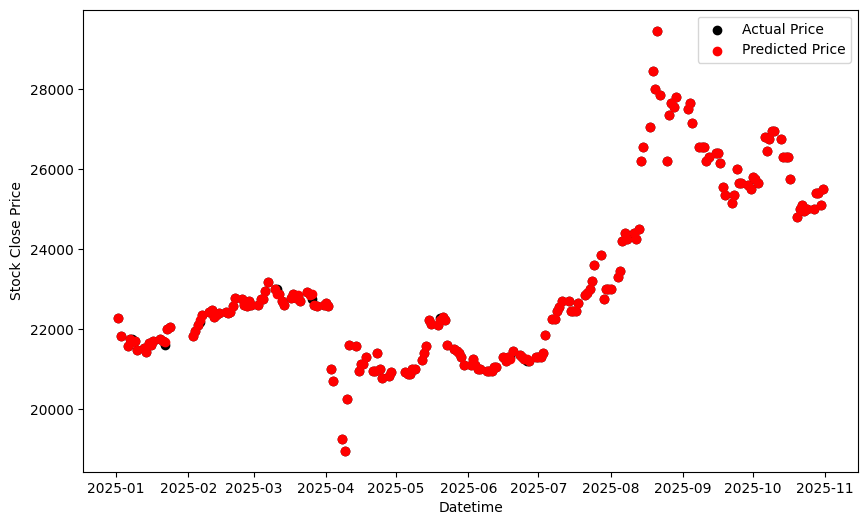

In [6]:
# Đảm bảo cột 'Datetime' được hiểu là kiểu dữ liệu datetime
data['Datetime'] = pd.to_datetime(data['Datetime'])

# Sắp xếp dataframe theo thời gian
data.sort_values(by='Datetime', inplace=True) 

# Tạo một đặc trưng mới có thể là ngày (hoặc một đặc trưng khác) để sử dụng trong mô hình
# Trong ví dụ này, giả sử bạn muốn sử dụng giá mở (Open) làm đặc trưng
# X = data[['Open']] # Features O, H, L, C, V tron tu 1 bien den 5 bien
X = data[['Open', 'High', 'Low']]
# Sử dụng cột 'Close' làm target => Gia dong cua ngay hom qua, quyet gia dong cua ngay hom
y = data['Close']

# Khởi tạo và huấn luyện mô hình cây quyết định
# Mo hinh Decision Tree Regressor
# Chia dữ liệu thành tập huấn luyện và tập kiểm thử
model = DecisionTreeRegressor()
model.fit(X, y)

# Dự đoán giá cổ phiếu trên toàn bộ tập dữ liệu
predictions = model.predict(X)

# Đánh giá hiệu suất mô hình bằng cách sử dụng Mean Squared Error (MSE)
mse = mean_squared_error(y, predictions)
print(f"Mean Squared Error: {mse}")

plt.figure(figsize=(10, 6))
# Vẽ biểu đồ so sánh giữa giá thực tế và giá dự đoán
plt.scatter(data['Datetime'], y, color='black', label='Actual Price')
plt.scatter(data['Datetime'], predictions, color='red', label='Predicted Price')
plt.xlabel('Datetime')
plt.ylabel('Stock Close Price')
plt.legend()
plt.show()


# Gan ket qua du doan vao Dataframe data

In [7]:
data['Predict_Close'] = predictions
data

,Datetime,Adj Close,Close,High,Low,Open,Volume,Predict_Close
0,2025-01-02,21258.912109,22260.869141,22347.826172,22086.957031,22260.869141,5901026,22260.869141
1,2025-01-03,20843.701172,21826.087891,22217.390625,21826.087891,22173.912109,25634673,21826.087891
2,2025-01-06,20594.570312,21565.216797,21782.609375,21521.738281,21739.130859,18844613,21565.216797
3,2025-01-07,20760.656250,21739.130859,21782.609375,21565.216797,21565.216797,5775479,21739.130859
4,2025-01-08,20760.656250,21739.130859,21739.130859,21565.216797,21739.130859,5200467,21673.913086
...,...,...,...,...,...,...,...,...
201,2025-10-27,25000.000000,25000.000000,25550.000000,24950.000000,25300.000000,10538950,25000.000000
202,2025-10-28,25400.000000,25400.000000,25400.000000,25050.000000,25100.000000,10313390,25400.000000
203,2025-10-29,25400.000000,25400.000000,25550.000000,25300.000000,25400.000000,36658230,25400.000000
204,2025-10-30,25100.000000,25100.000000,25700.000000,25000.000000,25500.000000,9720545,25100.000000


# Kiem tra do chenh lech giua gia thuc te va gia du doan

In [8]:
# Check xem ket qua co chap nhan duoc khong
data['Percent_Pc_C'] = ( data['Predict_Close'] - data['Close'] ) / data['Close'] * 100

data['Chap nhan'] = ''
# data['Chap nhan'] = 'Chấp nhận' if abs(data['Percent_Pc_C']) <= 1 else 'Không chấp nhận'
data['Chap nhan'] = data['Percent_Pc_C'].apply(lambda x: 'Chap nhan' if abs(x) <= 1 else 'Khong chap nhan')

data

# Vi du: Do chenh lech < 1% la "Chap nhan" => Nguoc lai: Xuat ghi la "Khong chap nhan"

,Datetime,Adj Close,Close,High,Low,Open,Volume,Predict_Close,Percent_Pc_C,Chap nhan
0,2025-01-02,21258.912109,22260.869141,22347.826172,22086.957031,22260.869141,5901026,22260.869141,0.000000,Chap nhan
1,2025-01-03,20843.701172,21826.087891,22217.390625,21826.087891,22173.912109,25634673,21826.087891,0.000000,Chap nhan
2,2025-01-06,20594.570312,21565.216797,21782.609375,21521.738281,21739.130859,18844613,21565.216797,0.000000,Chap nhan
3,2025-01-07,20760.656250,21739.130859,21782.609375,21565.216797,21565.216797,5775479,21739.130859,0.000000,Chap nhan
4,2025-01-08,20760.656250,21739.130859,21739.130859,21565.216797,21739.130859,5200467,21673.913086,-0.300002,Chap nhan
...,...,...,...,...,...,...,...,...,...,...
201,2025-10-27,25000.000000,25000.000000,25550.000000,24950.000000,25300.000000,10538950,25000.000000,0.000000,Chap nhan
202,2025-10-28,25400.000000,25400.000000,25400.000000,25050.000000,25100.000000,10313390,25400.000000,0.000000,Chap nhan
203,2025-10-29,25400.000000,25400.000000,25550.000000,25300.000000,25400.000000,36658230,25400.000000,0.000000,Chap nhan
204,2025-10-30,25100.000000,25100.000000,25700.000000,25000.000000,25500.000000,9720545,25100.000000,0.000000,Chap nhan


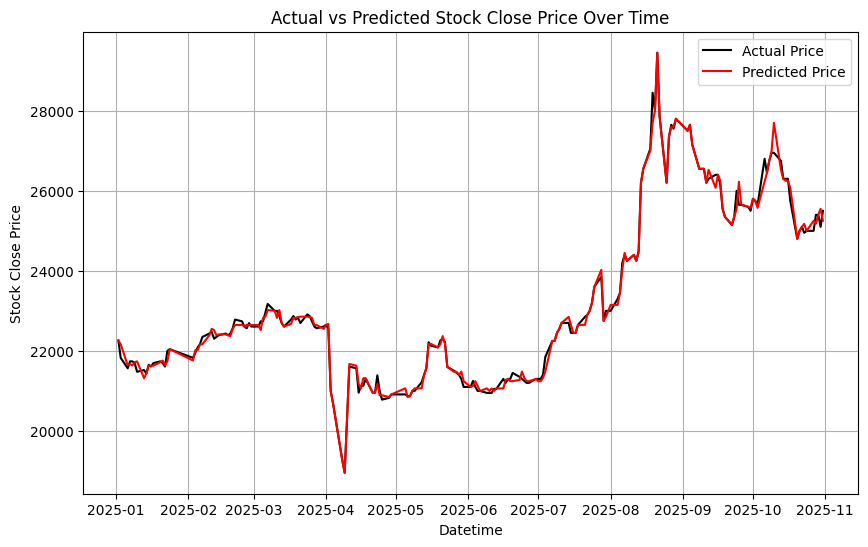

In [24]:
# Vẽ biểu đồ đường của giá cổ phiếu thực tế và giá cổ phiếu dự đoán
plt.figure(figsize=(10, 6))
plt.plot(data['Datetime'], y, label='Actual Price', color='black')
plt.plot(data['Datetime'], predictions, label='Predicted Price', color='red')
plt.xlabel('Datetime')
plt.ylabel('Stock Close Price')
plt.title('Actual vs Predicted Stock Close Price Over Time')
plt.legend()
plt.grid(True)
plt.show()


In [25]:
# Lấy cây quyết định từ mô hình
tree = model.tree_

# Hiển thị quy tắc quyết định trong cây
print("Decision Tree Rules:")
print('Node count', tree.node_count)
for node in range(tree.node_count):
    feature = tree.feature[node]
    threshold = tree.threshold[node]
    if tree.children_left[node] == tree.children_right[node]:  # Node lá
        value = tree.value[node]
        print(f"Leaf node {node}: Predicted value = {value}")
    else:  # Node chia
        print(f"Node {node}: If feature {feature} <= {threshold}, go to node {tree.children_left[node]}, else go to node {tree.children_right[node]}")


Decision Tree Rules:
Node count 243
Node 0: If feature 0 <= 24100.0, go to node 1, else go to node 156
Node 1: If feature 0 <= 21891.3037109375, go to node 2, else go to node 77
Node 2: If feature 0 <= 20543.478515625, go to node 3, else go to node 10
Node 3: If feature 0 <= 18891.3046875, go to node 4, else go to node 5
Leaf node 4: Predicted value = [[18956.52148438]]
Node 5: If feature 0 <= 19913.0439453125, go to node 6, else go to node 7
Leaf node 6: Predicted value = [[20695.65234375]]
Node 7: If feature 0 <= 20173.9130859375, go to node 8, else go to node 9
Leaf node 8: Predicted value = [[19260.86914062]]
Leaf node 9: Predicted value = [[20260.86914062]]
Node 10: If feature 0 <= 21417.3916015625, go to node 11, else go to node 52
Node 11: If feature 0 <= 21233.6953125, go to node 12, else go to node 37
Node 12: If feature 0 <= 20934.7822265625, go to node 13, else go to node 16
Node 13: If feature 0 <= 20869.5654296875, go to node 14, else go to node 15
Leaf node 14: Predicted 

# Chia huan luyen (train) ra 90%, con test 10%

Mean Squared Error: 112500.0


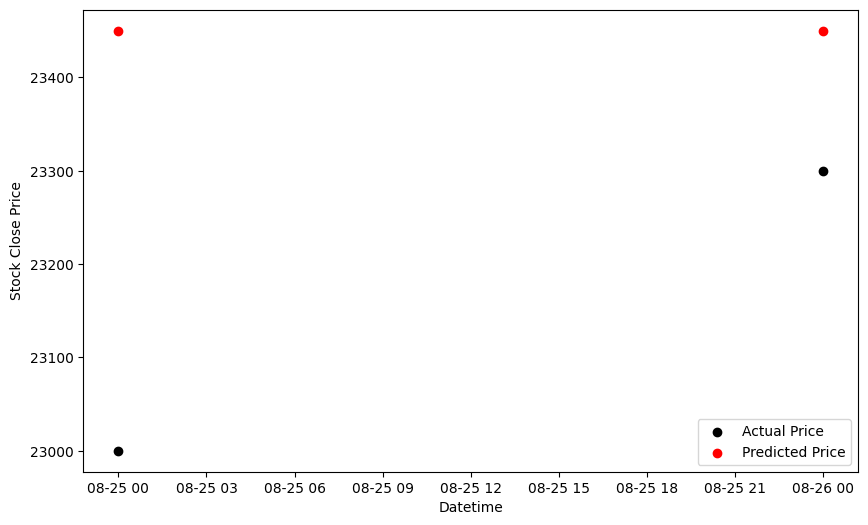

In [12]:

# Đảm bảo cột 'Datetime' được hiểu là kiểu dữ liệu datetime
data['Datetime'] = pd.to_datetime(data['Datetime'])

# Sắp xếp dataframe theo thời gian
data.sort_values(by='Datetime', inplace=True)

# Tạo một đặc trưng mới có thể là ngày (hoặc một đặc trưng khác) để sử dụng trong mô hình
# Trong ví dụ này, giả sử bạn muốn sử dụng giá mở (Open) làm đặc trưng
X = data[['Open']]

# Sử dụng cột 'Close' làm target
y = data['Close']

# Chia dữ liệu thành tập huấn luyện và tập kiểm thử
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42) # 90% train, 10% test

# Khởi tạo và huấn luyện mô hình cây quyết định
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

# Dự đoán giá cổ phiếu trên tập kiểm thử
predictions = model.predict(X_test)

# Đánh giá hiệu suất mô hình bằng cách sử dụng Mean Squared Error (MSE)
mse = mean_squared_error(y_test, predictions)
print(f"Mean Squared Error: {mse}")

plt.figure(figsize=(10, 6))

# Vẽ biểu đồ so sánh giữa giá thực tế và giá dự đoán
plt.scatter(data['Datetime'].iloc[-len(X_test):], y_test, color='black', label='Actual Price')
plt.scatter(data['Datetime'].iloc[-len(X_test):], predictions, color='red', label='Predicted Price')
plt.xlabel('Datetime')
plt.ylabel('Stock Close Price')
plt.legend()
plt.show()



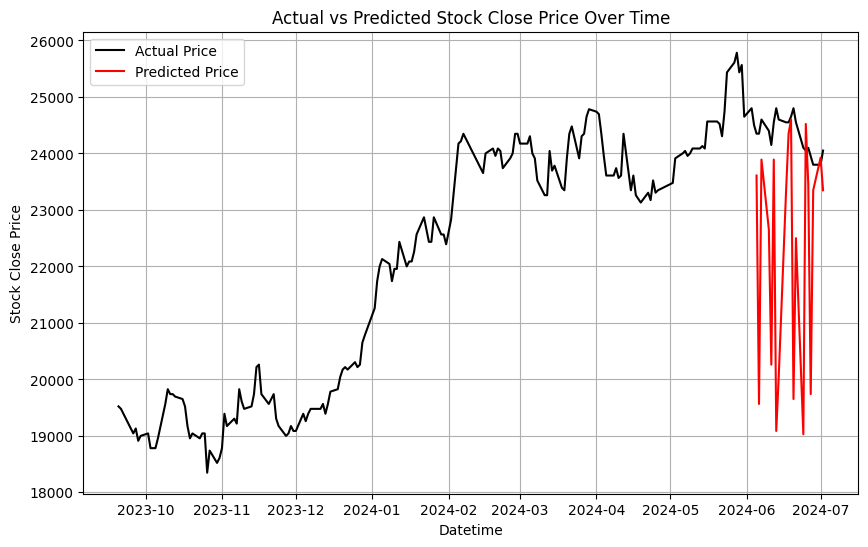

In [15]:
# Vẽ biểu đồ đường đi của giá cổ phiếu thực tế
plt.figure(figsize=(10, 6))
plt.plot(data['Datetime'], data['Close'], label='Actual Price', color='black')

# Vẽ biểu đồ đường đi của giá cổ phiếu dự đoán
plt.plot(data['Datetime'].iloc[-len(X_test):], predictions, label='Predicted Price', color='red')

plt.title('Actual vs Predicted Stock Close Price Over Time')
plt.xlabel('Datetime')
plt.ylabel('Stock Close Price')
plt.legend()
plt.grid(True)
plt.show()
